In [20]:
import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd
import matplotlib.pyplot as plt
import sys
from pathlib import Path

# Add project root to path
project_root = project_root = Path(r'C:\Users\walimunige.rupasingh\OneDrive - University of Calgary\Documents\GitHub\ENSO_effects_SD')
sys.path.append(str(project_root))

In [28]:
# Configuration
config = {
    'SWEI_8mo_input_data': project_root / 'data' / 'input_data' / 'bow_casr_swei_8mo.csv',
    'SWEI_1mo_input_data': project_root / 'data' / 'input_data' / 'bow_casr_swei_1mo.csv',
    'ENSO_input_data': project_root / 'data' / 'input_data' / 'teleconnection_indices.csv',
    'output_dir': project_root / 'data' / 'output_data',
    'plots_dir': project_root / 'data' / 'output_plots',
}

In [38]:
# load data and convert to dataframes
# Load seasonal SWEI data
swei_8mo_data = pd.read_csv(config['SWEI_8mo_input_data'])
swei_8mo_data['time'] = pd.to_datetime(swei_8mo_data['time'])

swei_8mo_data = swei_8mo_data.drop(columns=['lat', 'lon','SWE_monthly', 'SWE_8mo', 'Gringorten_p'])

display(swei_8mo_data.head())


,station_id,time,Seasonal_Year,month,SWEI,Elevation_Category
0,1,1981-05-01,1980,5,0.142516,2000_2500m
1,1,1982-05-01,1981,5,0.637153,2000_2500m
2,1,1983-05-01,1982,5,0.503394,2000_2500m
3,1,1984-05-01,1983,5,-0.200177,2000_2500m
4,1,1985-05-01,1984,5,-0.378110,2000_2500m


In [40]:
# average over Elevation_category
swei_8mo_data_avg = swei_8mo_data.groupby(['Elevation_Category', 'Seasonal_Year'])['SWEI'].mean().reset_index()
display(swei_8mo_data_avg.head())

,Elevation_Category,Seasonal_Year,SWEI
0,1000_1500m,1980,-0.778473
1,1000_1500m,1981,0.320094
2,1000_1500m,1982,-0.942805
3,1000_1500m,1983,-0.356098
4,1000_1500m,1984,-0.147442


In [41]:
# Load seasonal SWEI data
swei_1mo_data = pd.read_csv(config['SWEI_1mo_input_data'])
swei_1mo_data['time'] = pd.to_datetime(swei_1mo_data['time'])

swei_1mo_data = swei_1mo_data.drop(columns=['lat', 'lon','SWE_monthly', 'SWE_1mo', 'Gringorten_p'])

display(swei_1mo_data.head())

,Grid_id,time,Seasonal_Year,month,SWEI,Elevation_Category
0,1,1980-01-01,1979,1,-0.460176,2000_2500m
1,1,1980-02-01,1979,2,-1.275513,2000_2500m
2,1,1980-03-01,1979,3,-0.963879,2000_2500m
3,1,1980-04-01,1979,4,-0.799917,2000_2500m
4,1,1980-05-01,1979,5,-1.817445,2000_2500m


In [42]:
# average over Elevation_category
swei_1mo_data_avg = swei_1mo_data.groupby(['Elevation_Category', 'Seasonal_Year','month'])['SWEI'].mean().reset_index()
display(swei_1mo_data_avg.head())

,Elevation_Category,Seasonal_Year,month,SWEI
0,1000_1500m,1979,1,-0.176177
1,1000_1500m,1979,2,-0.285236
2,1000_1500m,1979,3,0.576678
3,1000_1500m,1979,4,0.054467
4,1000_1500m,1979,5,-1.277842


In [26]:
# Load ENSO data
enso_data = pd.read_csv(config['ENSO_input_data'])

# choose data for years 1980-2024 and month 10,11,12,1,2,3,4,5
enso_data = enso_data[(enso_data['Year'] >= 1980)  & (enso_data['Year'] <= 2024) & (enso_data['Month'].isin([10,11,12,1,2,3,4,5]))]

# Drop NAO
enso_data = enso_data.drop(columns=['NAO'])

display(enso_data.head())

,Year,Month,ENSO
29,1980,1,0.7
30,1981,1,0.6
31,1982,1,2.0
32,1983,1,-5.8
33,1984,1,0.3


In [44]:
# yearly average of ENSO data
enso_data_yearly = enso_data.groupby('Year').mean().reset_index().drop(columns=['Month'])
display(enso_data_yearly.head())

,Year,ENSO
0,1980,-0.1500
1,1981,-0.0250
2,1982,-0.9875
3,1983,-1.9750
4,1984,0.2375


In [66]:
# merge ENSO data with SWEI data
merged_data_8mo = pd.merge(swei_8mo_data_avg, enso_data_yearly, left_on='Seasonal_Year', right_on='Year').round(1)
merged_data_1mo = pd.merge(swei_1mo_data_avg, enso_data, left_on=['Seasonal_Year', 'month'], right_on=['Year', 'Month'])
display(merged_data_8mo.head())
display(merged_data_1mo.head())

,Elevation_Category,Seasonal_Year,SWEI,Year,ENSO
0,1000_1500m,1980,-0.8,1980,-0.2
1,1500_2000m,1980,-0.6,1980,-0.2
2,2000_2500m,1980,-0.4,1980,-0.2
3,500_1000m,1980,-0.1,1980,-0.2
4,1000_1500m,1981,0.3,1981,-0.0


,Elevation_Category,Seasonal_Year,month,SWEI,Year,Month,ENSO
0,1000_1500m,1980,1,-1.584790,1980,1,0.7
1,1500_2000m,1980,1,-1.589833,1980,1,0.7
2,2000_2500m,1980,1,-0.623074,1980,1,0.7
3,500_1000m,1980,1,-0.711368,1980,1,0.7
4,1000_1500m,1980,2,-0.769448,1980,2,0.5


In [67]:
# save merged data
merged_data_8mo.to_csv(config['output_dir'] / 'SWEI_nino_data_8mo.csv', index=False)
merged_data_1mo.to_csv(config['output_dir'] / 'SWEI_nino_data_1mo.csv', index=False)

# Time series

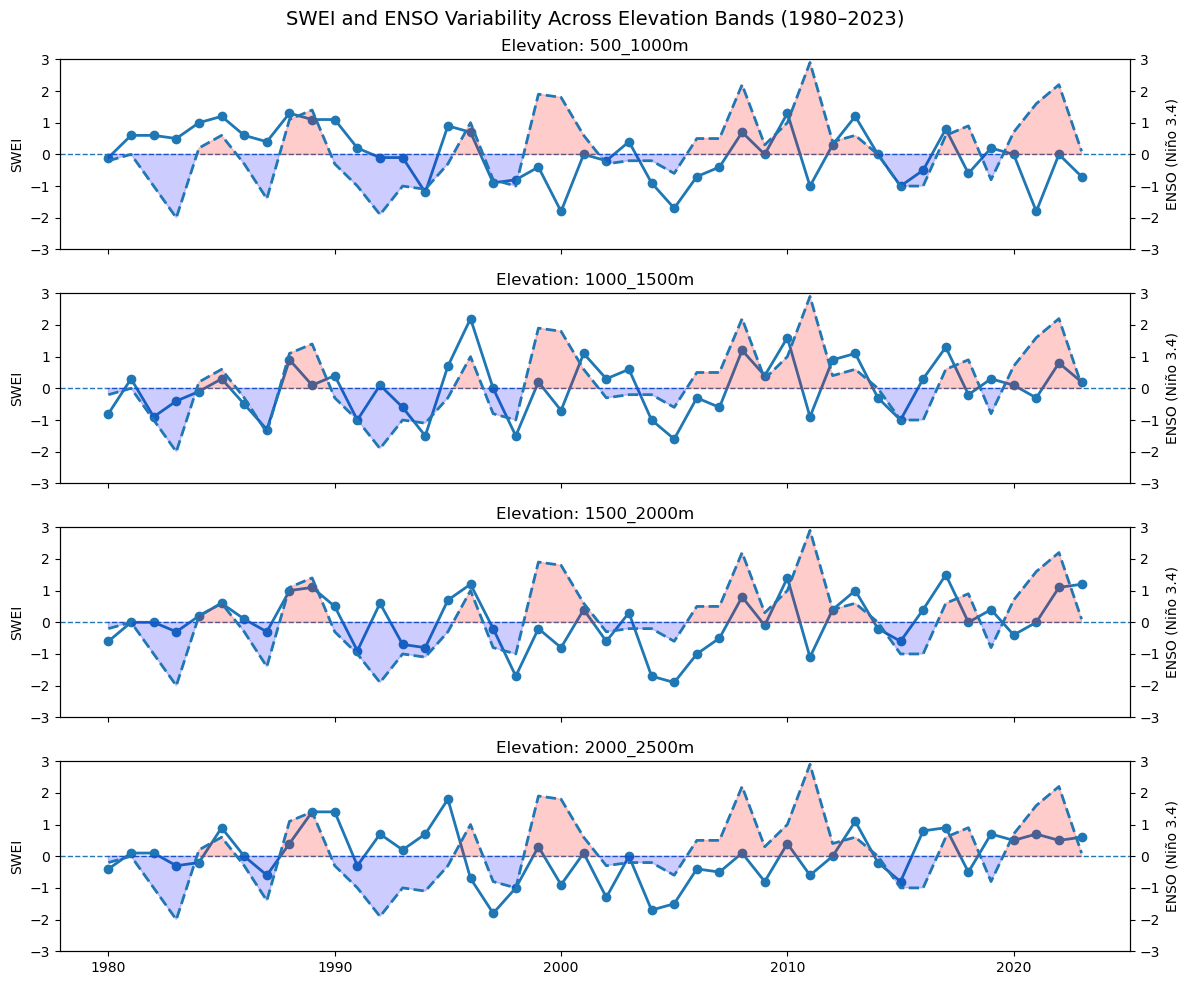

In [ ]:
# sort data - seasonal
df = merged_data_8mo.sort_values(['Elevation_Category', 'Seasonal_Year'])

# unique elevation categories (ordered)
elevations = ['500_1000m', '1000_1500m', '1500_2000m', '2000_2500m']

fig, axes = plt.subplots(len(elevations), 1, figsize=(12, 10), sharex=True)

for i, elev in enumerate(elevations):
    ax = axes[i]
    
    subset = merged_data_8mo[merged_data_8mo['Elevation_Category'] == elev]
    
    # SWEI (primary axis)
    ax.plot(subset['Seasonal_Year'], subset['SWEI'],
            marker='o', linewidth=2)
    ax.set_ylabel('SWEI')
    ax.axhline(0, linestyle='--', linewidth=1)
    ax.set_ylim(-3, 3)
    
    # secondary axis for ENSO
    ax2 = ax.twinx()
    ax2.plot(subset['Seasonal_Year'], subset['ENSO'],
             linestyle='--', linewidth=2)
    ax2.set_ylabel('ENSO (Niño 3.4)')
    ax2.set_ylim(-3, 3)
    
    # title per panel
    ax.set_title(f'Elevation: {elev}')
    
    # optional: highlight El Niño (>0.5) and La Niña (<-0.5)
    ax2.fill_between(subset['Seasonal_Year'],
                                 subset['ENSO'], 0,
                                 where=subset['ENSO'] >0,
                                 color='red',
                                 alpha=0.2,
                                 interpolate=True)
    
    ax2.fill_between(subset['Seasonal_Year'],
                     subset['ENSO'], 0,
                     where=subset['ENSO'] <0,
                     color='blue',
                     alpha=0.2,
                     interpolate=True)

# shared x-label
plt.xlabel('Year')

# main title
plt.suptitle('SWEI and ENSO Variability Across Elevation Bands (1980–2023)', fontsize=14)

plt.tight_layout()
plt.show()

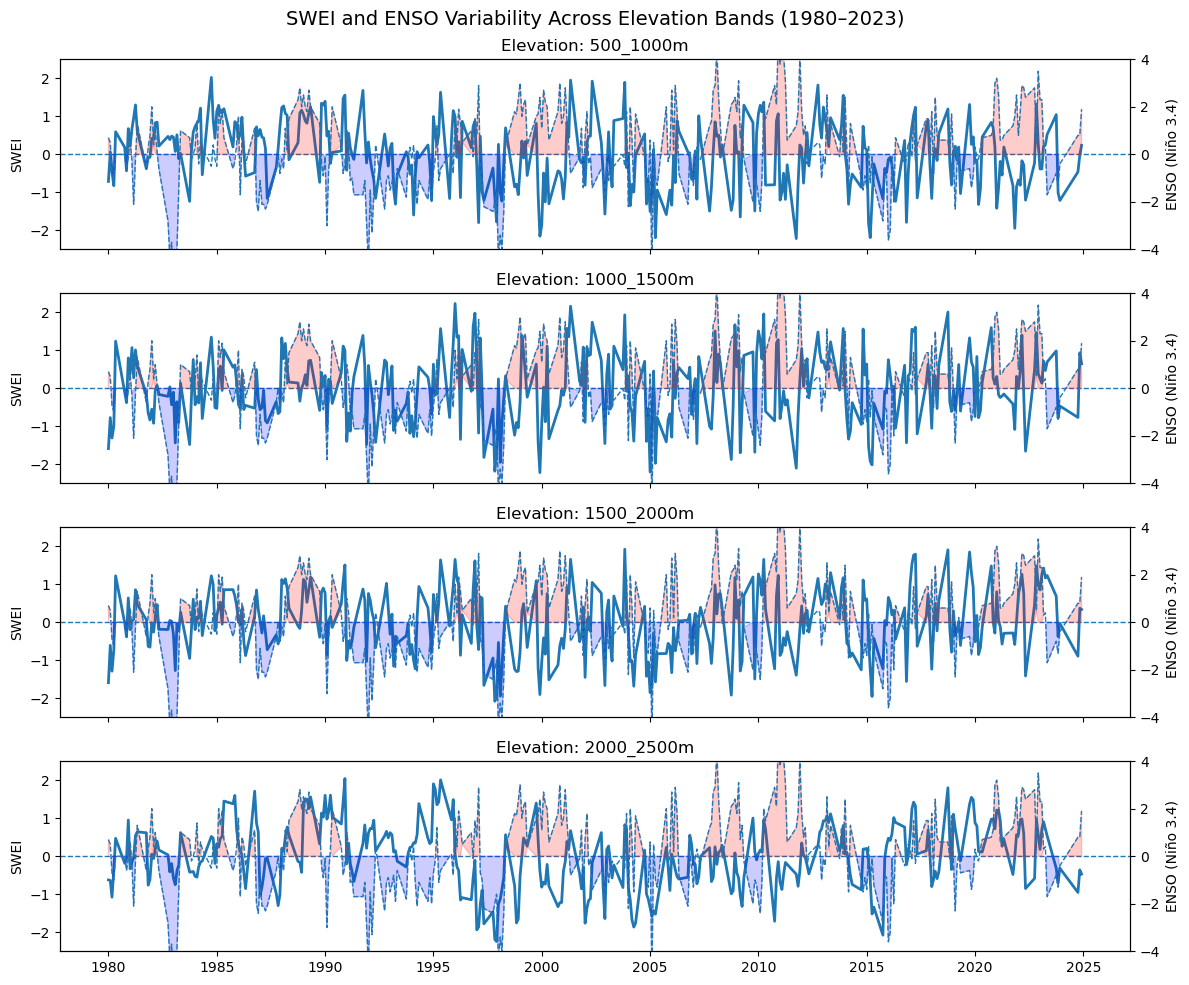

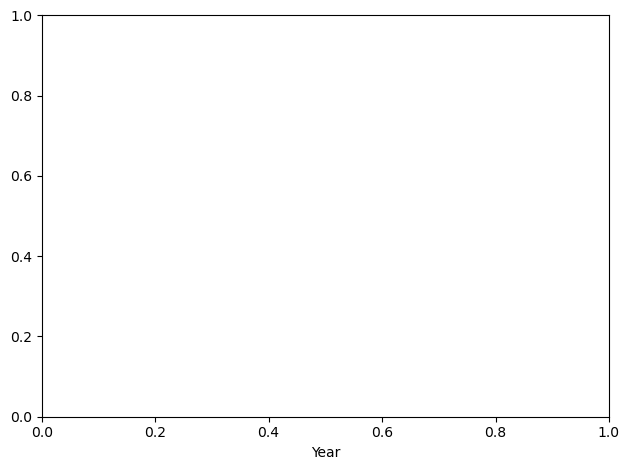

In [80]:
# sort data - monthly
df = merged_data_1mo.sort_values(['Elevation_Category', 'Seasonal_Year'])

# unique elevation categories (ordered)
elevations = ['500_1000m', '1000_1500m', '1500_2000m', '2000_2500m']

fig, axes = plt.subplots(len(elevations), 1, figsize=(12, 10), sharex=True)

for i, elev in enumerate(elevations):
        ax = axes[i]
        
        subset = merged_data_1mo[merged_data_1mo['Elevation_Category'] == elev].copy()
        
        # combine year and month for plotting
        x = pd.to_datetime(dict(year=subset['Seasonal_Year'], month=subset['month'], day=1))

        # SWEI (primary axis)
        ax.plot(x, subset['SWEI'],  linewidth=2)
        ax.set_ylabel('SWEI')
        ax.axhline(0, linestyle='--', linewidth=1)
        ax.set_ylim(-2.5, 2.5)

        # secondary axis for ENSO
        ax2 = ax.twinx()
        ax2.plot(x, subset['ENSO'], linestyle='--', linewidth=1)
        ax2.set_ylabel('ENSO (Niño 3.4)')
        ax2.set_ylim(-4, 4)
        
        # title per panel
        ax.set_title(f'Elevation: {elev}')
        
        # highlight El Niño (>0.5) and La Niña (<-0.5)
        ax2.fill_between(x, subset['ENSO'], 0, where=subset['ENSO'] > 0.5, alpha=0.2, color='red',interpolate=True)
        ax2.fill_between(x, subset['ENSO'], 0, where=subset['ENSO'] < -0.5, alpha=0.2, color='blue',interpolate=True)

# shared x-label
plt.xlabel('Year')

# main title
plt.suptitle('SWEI and ENSO Variability Across Elevation Bands (1980–2023)', fontsize=14)

plt.tight_layout()
plt.show()

# shared x-label
plt.xlabel('Year')

plt.tight_layout()
plt.show()